# 1. Imports

In [9]:
!pip install pyautogui

  Using cached pyautogui-0.9.54-py3-none-any.whl
  Using cached pytweening-1.2.0-py3-none-any.whl
  Using cached pyscreeze-1.0.1-py3-none-any.whl
  Using cached pygetwindow-0.0.9-py3-none-any.whl
  Using cached mouseinfo-0.1.3-py3-none-any.whl
  Using cached pyrect-0.2.0-py2.py3-none-any.whl


In [1]:
import cv2
import numpy as np
import mediapipe as mp
import time
import os
import pyautogui
from scipy.spatial.distance import pdist
from matplotlib import pyplot as plt
from google.protobuf.json_format import MessageToDict
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from itertools import zip_longest

# 2. Segmentation function

In [2]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [3]:
def draw_styled_landmarks(image, results):
    if results.multi_hand_landmarks:  # sprawdzamy, czy są wykryte ręce
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
            )

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION (OPENCV)BGR TO (MEDIAPIPE)RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION (MEDIAPIPE)RGB TO (OPENCV)BGR
    return image, results

In [5]:
VIDEO_PATH = '../Recording4.avi'
cap = cv2.VideoCapture(VIDEO_PATH)

gestures_counter_right = 0
gestures_counter_left = 0
frames_counter = 0
distances_over_time_left = []
distances_over_time_right = []
paused = False
visible_hands_counter = 0


with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.50,
    min_tracking_confidence=0.50
) as hands:

    while True:
        if not paused:
            ret, frame = cap.read()
            if not ret:
                break

            image, results = mediapipe_detection(frame, hands)
            image = cv2.resize(image, (650, 500))
            
            is_left_hand = False
            is_right_hand = False
            
            left_vec = np.zeros(15)
            right_vec = np.zeros(15)

            if results.multi_handedness and results.multi_hand_landmarks:
                visible_hands_counter = 0
                for hand_label, hand_landmarks in zip(results.multi_handedness, results.multi_hand_landmarks):
                    label = MessageToDict(hand_label)['classification'][0]['label']
                    finger_tips = [hand_landmarks.landmark[i] for i in [0, 4, 8, 12, 16, 20]]
                    points = np.array([[p.x, p.y, p.z] for p in finger_tips])
                    distances = pdist(points)

                    if label == 'Left':
                        left_vec = distances
                        is_left_hand = True

                    if label == 'Right':
                        right_vec = distances
                        is_right_hand = True

            if not is_left_hand:
                if distances_over_time_left:
                    left_vec = distances_over_time_left[-1]
                        
            if not is_right_hand:
                if distances_over_time_right:
                    right_vec = distances_over_time_right[-1]
                    
            if visible_hands_counter == 10:
                left_vec = np.random.rand(15)
                right_vec = np.random.rand(15)
            
            distances_over_time_left.append(left_vec)
            distances_over_time_right.append(right_vec)
            visible_hands_counter += 1

            cv2.putText(image, f"klatka: {frames_counter}", (20, 50),
                        cv2.FONT_HERSHEY_COMPLEX, 0.9, (0, 255, 0), 2)

            draw_styled_landmarks(image, results)
            frames_counter += 1

        # dla gestow warto robic -5 klatek odejmujac od konca (nagranie 232 klatek)
        # if frames_counter >= 19 and frames_counter <= 53:
        # if frames_counter >= 58 and frames_counter <= 91:
        # if frames_counter >= 96 and frames_counter <= 140:   
        # if frames_counter >= 145 and frames_counter <= 171:
        # if frames_counter >= 176 and frames_counter <= 215: 
            cv2.imshow("Capturing", image)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord(' '):  
            paused = not paused

cap.release()
cv2.destroyAllWindows()

combined_distances = [np.concatenate([l, r]) for l, r in zip(distances_over_time_left, distances_over_time_right)]


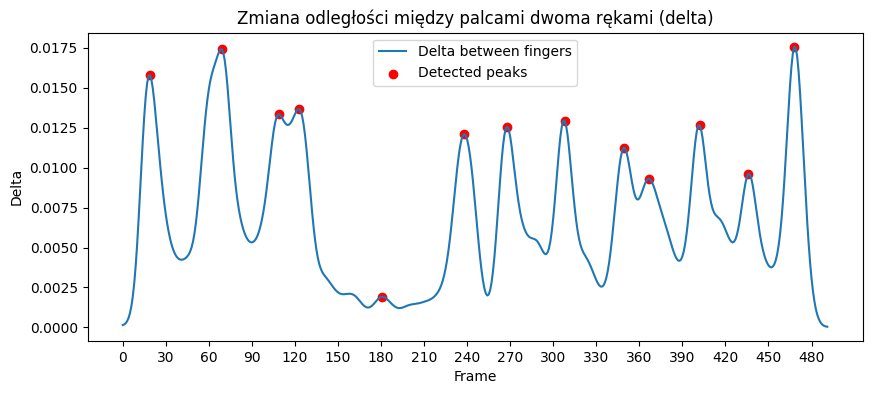

In [11]:
# BEST
if len(combined_distances) > 1:
    deltas = []
    lookaround = 10 

    for i in range(len(combined_distances)):
        look_deltas = []

        for j in range(1, lookaround + 1):
            if i - j >= 0:
                delta_back = abs(combined_distances[i] - combined_distances[i - j])
                look_deltas.append(delta_back)
            if i + j < len(combined_distances):
                delta_forward = abs(combined_distances[i] - combined_distances[i + j])
                look_deltas.append(delta_forward)

        if look_deltas:
            median_delta = np.median(look_deltas)
            deltas.append(median_delta)
        else:
            deltas.append(0)

        
    delta_smooth = gaussian_filter1d(deltas, sigma=4)
    peaks, _ = find_peaks(delta_smooth, prominence=0.0001, distance=10)

    plt.figure(figsize=(10,4))
    plt.plot(delta_smooth, label='Delta between fingers')
    plt.scatter(peaks, delta_smooth[peaks], color='red', label='Detected peaks')
    plt.title("Zmiana odległości między palcami dwoma rękami (delta)")
    plt.xticks(range(0, len(delta_smooth), 30))
    plt.xlabel("Frame")
    plt.ylabel("Delta")
    plt.legend()
    plt.show()

In [482]:
# if len(combined_distances) > 1:
#     deltas = []
#     lookaround = 10 

#     for i in range(len(combined_distances)):
#         look_deltas = []

#         for j in range(1, lookaround + 1):
#             if i - j >= 0:
#                 delta_back = np.linalg.norm(combined_distances[i] - combined_distances[i - j])
#                 look_deltas.append(delta_back)
#             if i + j < len(combined_distances):
#                 delta_forward = np.linalg.norm(combined_distances[i] - combined_distances[i + j])
#                 look_deltas.append(delta_forward)

#         if look_deltas:
#             median_delta = np.median(look_deltas)
#             deltas.append(median_delta)
#         else:
#             deltas.append(0)

        
#     delta_smooth2 = gaussian_filter1d(deltas, sigma=4)
#     peaks, _ = find_peaks(delta_smooth2, prominence=0.001, distance=15)

#     plt.figure(figsize=(10,4))
#     plt.plot(delta_smooth2, label='Delta between fingers')
#     plt.scatter(peaks, delta_smooth2[peaks], color='red', label='Detected peaks')
#     plt.title("2 - Zmiana odległości między palcami dwoma rękami (delta)")
#     plt.xticks(range(0, len(delta_smooth2), 30))
#     plt.xlabel("Frame")
#     plt.ylabel("Delta")
#     plt.legend()
#     plt.show()

    
    
#     # peaks, _ = find_peaks(delta_smooth, prominence=0.001, distance=15)

#     # plt.figure(figsize=(10,4))
#     # plt.plot(delta_smooth, label='Delta between fingers')
#     # plt.scatter(peaks, delta_smooth[peaks], color='red', label='Detected peaks')
#     # plt.title("Zmiana odległości między palcami dwoma rękami (delta)")
#     # plt.xticks(range(0, len(delta_smooth), 30))
#     # plt.xlabel("Frame")
#     # plt.ylabel("Delta")
#     # plt.legend()
#     # plt.show()
    

dla nagrania 232 klatek (Recording.avi):
<br>
- dla peaks prominence=0.001, distance=15, sigma=3
<br>
- max_lookaround - 10

dla nagrania 380 klatek (Recording3.avi):
<br>
- dla peaks prominence=0.001, distance=15, sigma=4
<br>
- max_lookaround - 10

dla nagrania 680 klatek (moje2.mp4):
<br>
- dla peaks prominence=0.001, distance=30(inny dystans prawdopodobnie przez przydlugie wykonywnie gestow), sigma=4
<br>
- max_lookaround - 10

In [13]:
sign_pattern = np.array([-5 if i > 0 else 0 for i in range(len(peaks))])
peaks_for_video_cuts = peaks -10

peaks_for_video_cuts

array([  9,  59,  99, 113, 171, 228, 258, 298, 339, 357, 392, 426, 458])

In [17]:
cap = cv2.VideoCapture('../Recording4.avi')

fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

num_parts = len(peaks_for_video_cuts)

for i in range(num_parts - 1):
    out = cv2.VideoWriter(f"output_part_{i+1}.mp4",
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          fps, (width, height))

    start_frame = peaks_for_video_cuts[i]
    end_frame = peaks_for_video_cuts[i+1]

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    for f in range(start_frame, end_frame):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    out.release()

cap.release()


In [ ]:
# if len(combined_distances) > 1:
#     deltas = []
#     max_lookback = 20

#     for i in range(1, len(combined_distances)):
#         lookback_deltas = []
#         for j in range(1, min(max_lookback + 1, i + 1)):
#             delta_j = np.linalg.norm(combined_distances[i] - combined_distances[i - j])
#             lookback_deltas.append(delta_j)

#         median_delta = np.min(lookback_deltas)
#         deltas.append(median_delta)

        
#     delta_smooth = gaussian_filter1d(deltas, sigma=1)
#     peaks, _ = find_peaks(delta_smooth, height=0.1, distance=15)

#     plt.figure(figsize=(10,4))
#     plt.plot(delta_smooth, label='Delta between fingers')
#     plt.scatter(peaks, delta_smooth[peaks], color='red', label='Detected peaks')
#     plt.title("Zmiana odległości między palcami dwoma rękami (delta)")
#     plt.xticks(range(0, len(delta_smooth), 30))
#     plt.xlabel("Frame")
#     plt.ylabel("Delta")
#     plt.legend()
#     plt.show()